In [1]:
import os
import librosa
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Data Engineering & Unimodal Pipelines

It is give that the third hyphen in the file name gives the Emotion, which is what we want to classify the audios by.

 - 01 = neutral
 - 02 = calm
 - 03 = happy
 - 04 = sad
 - 05 = angry
 - 06 = fearful
 - 07 = disgust
 - 08 = surprised

It is also given that the third-last hyphen is the dialogue.
  
 - 01 = "Kids are talking by the door"
 - 02 = "Dogs are sitting by the door"

Now, let's try to organize this data into a DataFrame so it is easier to work with.

In [2]:
emotion_dict = {
    '01': 1,
    '02': 2,
    '03': 3,
    '04': 4,
    '05': 5,
    '06': 6,
    '07': 7,
    '08': 8
}

dialogue_dict = {
    '01': 'kids',
    '02': 'dogs'
}

## Audio Preprocessing (CNN Input)

In [3]:
data = []

for folder in os.listdir("archive"):
    folder_path = os.path.join("archive", folder)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)
        y, sr = librosa.load(file_path, sr=None)        
        
        codes = file.split("-")

        emotion_code = codes[2]
        emotion = emotion_dict[emotion_code]

        dialogue_code = codes[-3]
        dialogue = dialogue_dict[dialogue_code]

        data.append({
            'array': y,
            'emotion': emotion_code,
            'dialogue': dialogue
        })
    
df = pd.DataFrame(data)
df.to_csv("audio.csv", index=False)
df

,array,emotion,dialogue
0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",01,kids
1,"[0.0, 0.0, -3.0517578e-05, 0.0, 0.0, 0.0, 0.0,...",01,kids
2,"[3.0517578e-05, 3.0517578e-05, 0.0, 3.0517578e...",01,dogs
3,"[3.0517578e-05, 3.0517578e-05, 3.0517578e-05, ...",01,dogs
4,"[3.0517578e-05, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",02,kids
...,...,...,...
1435,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",08,dogs
1436,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",08,kids
1437,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",08,kids
1438,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",08,dogs


(array([ 53., 204., 421., 396., 182., 118.,  37.,  21.,   6.,   2.]),
 array([2.93627083, 3.1698375 , 3.40340417, 3.63697083, 3.8705375 ,
        4.10410417, 4.33767083, 4.5712375 , 4.80480417, 5.03837083,
        5.2719375 ]),
 <BarContainer object of 10 artists>)

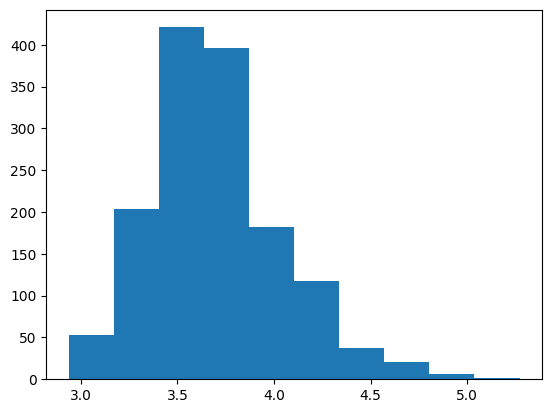

In [4]:
y, sr = librosa.load("archive/Actor_01/03-01-01-01-01-01-01.wav", sr=None)

lengths = np.array([len(x) for x in df['array']]) / sr
import matplotlib.pyplot as plt

plt.hist(lengths)

This is in issue, because clearly all the audios have different durations. And when feeding a CNN, all the Mel-Spectograms should be of the same dimension! So we will have to do padding (for shorter than target audios) and cutting (for longer than target audios). Our target audio length should be around 4 secoonds

In [5]:
def extract_mel_spectrogram(file_path):

    TARGET_DURATION = 4
    SR = 48000
    TARGET_LENGTH = TARGET_DURATION * SR

    y, sr = librosa.load(file_path, sr=None, duration=4)

    y = librosa.util.fix_length(y, size=TARGET_LENGTH) # makes all the durations the same

    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)

    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max) # this is just to convert it so the values arent too small

    return mel_spec_db

In [57]:
X, y = [], []

In [58]:
for folder in os.listdir("archive"):
    folder_path = os.path.join("archive", folder)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        emotion_code = file.split("-")[2]

        label = emotion_dict[emotion_code]

        mel_spec = extract_mel_spectrogram(file_path)

        X.append(mel_spec)
        y.append(label)

In [59]:
X = np.array(X)
y = np.array(y)
print(X.shape, y.shape)

(1440, 128, 376) (1440,)


CNNs generally expect input as (samples, height, width, channels), so we will add a channel dimension.

In [60]:
X = X[..., np.newaxis]
print(X.shape)


(1440, 128, 376, 1)


## Text Generation & Preprocessing (RNN Input)

In [10]:
!pip install openai-whisper

In [11]:
import whisper

model = whisper.load_model("tiny").to("cuda")

In [12]:
paths, texts, labels = [], [], []

In [13]:
result = model.transcribe(
    "archive/Actor_01/03-01-01-01-01-01-01.wav",
    fp16=True # makes the inference faster
)

print(result["text"])

 Kids are talking by the door.


In [14]:
for folder in os.listdir("archive"):
    folder_path = os.path.join("archive", folder)

    for file in os.listdir(folder_path):
        file_path = os.path.join(folder_path, file)

        result = model.transcribe(
            file_path,
            fp16=True # makes the inference faster
        )
        text = result["text"].lower() # so it is not case sensitive

        emotion = int(file.split("-")[2])

        texts.append(text)
        labels.append(emotion)
        paths.append(file_path)

In [35]:
df_text = pd.DataFrame({
    "path": paths,
    "text": texts,
    "emotion": labels
})

df_text.to_csv("transcripts_with_path.csv", index=False)

In [36]:
# df_text = pd.read_csv("transcripts_with_path.csv")

In [37]:
df_text["text"].unique()

array([' kids are talking by the door.', ' dogs are sitting by the door.',
       ' kids are talking by the door!', ' dogs are sitting by the door!',
       ' kids talking by the door', ' st',
       ' oh dogs are sitting by the door.',
       ' dugs are sitting by the door.', ' kids are talking by the tour.',
       ' toxic is sitting by the door.',
       ' talks are sitting by the door.',
       " kids, you're talking by the door?",
       ' kids are talking by the door',
       ' the kids are talking by the door.',
       ' kids are talking about the door!',
       ' cuts are talking by the door.',
       ' kids are talking about the door.',
       ' to observe sitting by the door.',
       " to oxford, you're sitting by the door.",
       ' dozens are sitting by the door!',
       ' dogs are sitting by the door?',
       ' a kids are talking by the door.',
       " kids, you're talking by the door.",
       ' tugs are sitting by the door.',
       ' ruh! dogs are sitting by the do

In [38]:
import re

df_text["clean_text"] = df_text["text"].apply(
    lambda x: re.sub(r"[^\w\s]", "", x.lower())
)

In [39]:
df_text["clean_text"].value_counts()

clean_text
kids are talking by the door            638
dogs are sitting by the door            611
kids are talking about the door          29
talks are sitting by the door            12
kid theyre talking by the door            6
                                       ... 
talks with sitting by the door            1
kids are talking with thor                1
dog zestering by engine                   1
dont watch their sitting by the door      1
dogs are setting by the door              1
Name: count, Length: 120, dtype: int64

As we can see, [639 + 611 = ] 1250 of our files have been correctly transcribed, so [1440 - 1250 = ] 190 of our files are incorrectly transcribed. Now, for simplicity sake, we can simply move on and ignore whatever is not transcribed correctly, but in doing so, we lose almost (190 / 1440 = ) 13% of our data. And as we can see, some of the other transcriptions are only small variations from what it actually is. So we will try to **normalize the noisy transcripts**.

We do this by mapping noisy text to the nearest valid sentence. And we know there are only two nearest valid sentences which are
 - "kids are talking by the door"
 - "dogs are sitting by the door"

A very simple normalization function would be to simply check whether the word "kid" is there in the transcription, and if it is, then assign it the first sentence. Similarly for "dog."

In [40]:
def normalize_text(text):
    if "kid" in text:
        return "kids are talking by the door"
    elif "dog" in text:
        return "dogs are sitting by the door"
    elif "talking" in text:
        return "kids are talking by the door"
    elif "sitting" in text:
        return "dogs are sitting by the door"
    else: return text

In [41]:
df_text["normalized_text"] = df_text["clean_text"].apply(
    normalize_text
)

In [42]:
df_text["normalized_text"].value_counts()

normalized_text
kids are talking by the door                 717
dogs are sitting by the door                 710
 st                                            1
 dont talk to her sick by the door             1
 keatez singing my guitar                      1
 dontussirl you in my god                      1
 doxer city in by the door                     1
 dont just sit in by the door                  1
 daskah dangerous combat ist jetzt wartet      1
 the boxing                                    1
 however staging by the door                   1
 dont say sinning by the door                  1
 dont just sit by the door                     1
 toxic is setting by the door                  1
 ich werde ihnen nichts bleiben                1
Name: count, dtype: int64

In [46]:
df_text[df_text["normalized_text"] == " ich werde ihnen nichts bleiben"] # lol

,path,text,emotion,clean_text,normalized_text
1017,archive\Actor_17\03-01-08-02-01-02-17.wav,ich werde ihnen nichts bleiben,8,ich werde ihnen nichts bleiben,ich werde ihnen nichts bleiben


Now, [696 + 639 = ] 1335 files have the correct label, [1440 - 1335 = ] 105 files have some different labels. Now, only [105 / 1440 = ] 7.2% of the data is useless. Since this is small, we can throw this data away. 

An even better normalization function would also check if "talking" and "sitting" are in the text, and classify accordingly. Using this, [716 + 711 = ] 1427 files are classified into our target texts, and only a mere [1440 - 1427 = ] 13 files are not. These can safely be discarded!

**What we have just done is kind of like a decision tree!**

In [47]:
VALID_TEXTS = [
    "kids are talking by the door",
    "dogs are sitting by the door"
]

df_text = df_text[df_text["normalized_text"].isin(VALID_TEXTS)]

In [48]:
df_text["normalized_text"].value_counts()

normalized_text
kids are talking by the door    717
dogs are sitting by the door    710
Name: count, dtype: int64

### Tokenization and Padding
Tokenization is done because neural networks don't understand text, but understand numbers. 
Padding is a method to make the lengths of all data tokens the same by adding 0s at the ends, because RNNs requere equal length sequences in a batch of data. But in our case, we severely preprocessed the data and split it into only 2 target strings, so obviously all the data will have sequences of equal length.

In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer

In [49]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df_text["normalized_text"])
print(tokenizer.word_index)

{'are': 1, 'by': 2, 'the': 3, 'door': 4, 'kids': 5, 'talking': 6, 'dogs': 7, 'sitting': 8}


In [50]:
sequences = tokenizer.texts_to_sequences(df_text["normalized_text"])

In [51]:
set([length for length in map(len, sequences)]) # all of our data have the same length

{6}

In [52]:
y_sequences = df_text["emotion"].values
y_sequences = y_sequences.astype(int) - 1
y_sequences

array([0, 0, 0, ..., 7, 7, 7], shape=(1427,))

## Unimodal Training

```X``` is our CNN input and ```sequences``` is out RNN input.

### Audio CNN

In [62]:
X1 = []

for path in df_text["path"]:
    mel = extract_mel_spectrogram(path)
    X1.append(mel)

X1 = np.array(X1)

In [68]:
X_train, X_test, y_train, y_test = train_test_split(
    X1,
    y_sequences,
    test_size=0.2,
    random_state=42,
    stratify=y_sequences
)

X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [69]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, Dropout)

In [70]:
model_cnn = Sequential([
    Conv2D(
        32, # number of kernels, also number of output feature maps
        (3,3), # dimensions of kernels
        activation="relu",
        input_shape=X_train.shape[1:]
    ),
    MaxPooling2D((2,2)),
    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(8, activation="softmax")
])

c:\Python 3.13\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


For the loss function, we need something which works well for Multi-Class Classification. So we will go with Categorical Cross-Entropy. The loss function is defined as

$$
L(y, \hat{y}) = - \sum_{i=1}^{c} y_i \log(\hat{y}_i)
$$

- $L(y, \hat{y})$ : Categorical Cross-Entropy loss  
- $y_i$ : True label for class $i$  
- $\hat{y}_i$ : Predicted probability for class $i$  
- $C$ : Number of classes

Sparse Categorical Cross-Entropy is another loss function, which yields the same loss and CCE but computes it in a different way. In Sparse CCE, it doesn't form a one-hot vector as CCE does, rather it simply yields the negative of the probability of correct class. This saves compute since it doesn't have to multiply the other probabilities by 0.


In [71]:
model_cnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [72]:
X_train.shape

(1141, 128, 376, 1)

In [78]:
history = model_cnn.fit( # this is where the CNN learns the best 32 kernels to fit
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 359ms/step - accuracy: 0.1656 - loss: 81.4011 - val_accuracy: 0.2273 - val_loss: 1.9992
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 12s 340ms/step - accuracy: 0.3479 - loss: 1.7789 - val_accuracy: 0.3217 - val_loss: 1.7845
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 13s 362ms/step - accuracy: 0.5004 - loss: 1.3696 - val_accuracy: 0.4301 - val_loss: 1.6027
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 379ms/step - accuracy: 0.6748 - loss: 0.9773 - val_accuracy: 0.3811 - val_loss: 1.6670
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 393ms/step - accuracy: 0.7616 - loss: 0.6783 - val_accuracy: 0.4231 - val_loss: 1.6324
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.8300 - loss: 0.4751 - val_accuracy: 0.5035 - val_loss: 1.5851
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 399ms/step - accuracy: 0.9299 - loss: 0.2266 - val_accuracy: 0.5140 - val_loss: 1.7878
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 14s 398ms/step - accuracy: 0.9535 - loss: 0.1449 - val_acc

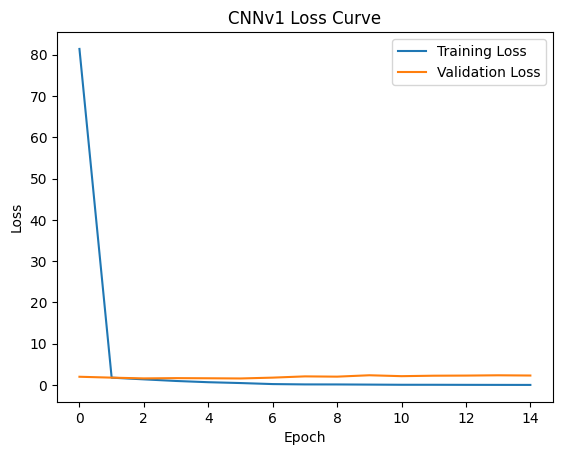

In [107]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNNv1 Loss Curve')
plt.legend()

plt.show()

In [80]:
model_cnn.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5175 - loss: 2.2973


[2.2972822189331055, 0.5174825191497803]

Severe overfitting since training accuracy = 0.9956 but testing accuracy = 0.5175.

### Text RNN

In [81]:
from sklearn.model_selection import train_test_split

X_train_sq, X_test_sq, y_train_sq, y_test_sq = train_test_split(
    sequences,
    y_sequences,
    test_size=0.2,
    random_state=42,
    stratify=y_sequences
)

In [82]:
from tensorflow.keras.layers import (Embedding, LSTM, Dense, Dropout, GRU)

In [83]:
vocab_size = len(tokenizer.word_index) + 1 # + 1 to account for unknown words
print(tokenizer.word_index)
print(vocab_size)

{'are': 1, 'by': 2, 'the': 3, 'door': 4, 'kids': 5, 'talking': 6, 'dogs': 7, 'sitting': 8}
9


In [84]:
model_rnn = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=16,
        input_length=len(sequences)
    ),
    LSTM(32), # RNN
    # CNN:
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(8, activation="softmax")
])

c:\Python 3.13\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [85]:
model_rnn.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [86]:
X_train_sq = np.array(X_train_sq)
X_test_sq = np.array(X_test_sq)

y_train_sq = np.array(y_train_sq)
y_test_sq = np.array(y_test_sq)

In [87]:
history_rnn = model_rnn.fit(
    X_train_sq,
    y_train_sq,
    epochs=100,
    batch_size=32,
    validation_data=(X_train_sq, y_train_sq)
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.1166 - loss: 2.0775 - val_accuracy: 0.1341 - val_loss: 2.0713
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1402 - loss: 2.0689 - val_accuracy: 0.1341 - val_loss: 2.0634
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1376 - loss: 2.0643 - val_accuracy: 0.1341 - val_loss: 2.0625
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1253 - loss: 2.0629 - val_accuracy: 0.1341 - val_loss: 2.0618
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1280 - loss: 2.0657 - val_accuracy: 0.1341 - val_loss: 2.0619
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1253 - loss: 2.0635 - val_accuracy: 0.1341 - val_loss: 2.0618
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1280 - loss: 2.0636 - val_accuracy: 0.1341 - val_loss: 2.0617
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1218 - loss: 2.0633 - val_accuracy: 0.1341 - v

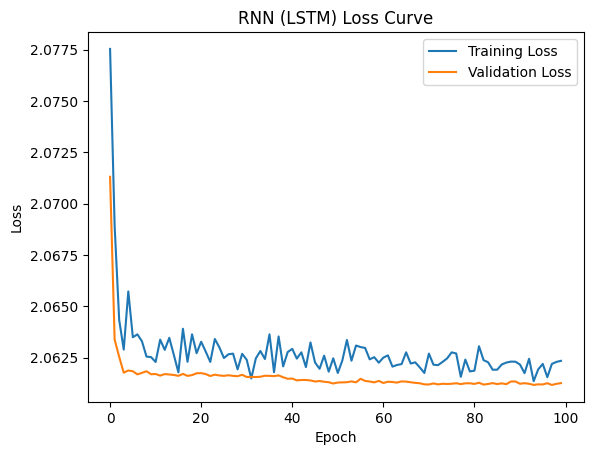

In [91]:
plt.plot(history_rnn.history['loss'], label='Training Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN (LSTM) Loss Curve')
plt.legend()

plt.show()

In [92]:
model_rnn.evaluate(
    X_train_sq,
    y_train_sq
)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1376 - loss: 2.0613 


[2.0612640380859375, 0.13759860396385193]

In [93]:
model_rnn2 = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=16,
        input_length=len(sequences)
    ),
    GRU(32), # RNN
    # CNN:
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dense(8, activation="softmax")
])

In [94]:
model_rnn2.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [95]:
history_rnn2 = model_rnn2.fit(
    X_train_sq,
    y_train_sq,
    epochs=100,
    batch_size=32,
    validation_data=(X_train_sq, y_train_sq)
)

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.1341 - loss: 2.0739 - val_accuracy: 0.1341 - val_loss: 2.0672
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1122 - loss: 2.0664 - val_accuracy: 0.1341 - val_loss: 2.0629
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1236 - loss: 2.0636 - val_accuracy: 0.1341 - val_loss: 2.0620
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1429 - loss: 2.0633 - val_accuracy: 0.1341 - val_loss: 2.0618
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1271 - loss: 2.0652 - val_accuracy: 0.1341 - val_loss: 2.0617
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1367 - loss: 2.0647 - val_accuracy: 0.1341 - val_loss: 2.0619
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1201 - loss: 2.0652 - val_accuracy: 0.1341 - val_loss: 2.0620
Epoch 8/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1350 - loss: 2.0630 - val_accuracy: 0.1341 - v

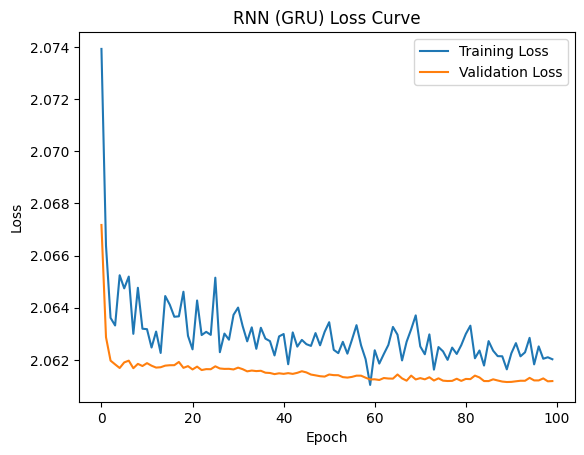

In [96]:
plt.plot(history_rnn2.history['loss'], label='Training Loss')
plt.plot(history_rnn2.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('RNN (GRU) Loss Curve')
plt.legend()

plt.show()

In [97]:
model_rnn2.evaluate(
    X_train_sq,
    y_train_sq
)

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1376 - loss: 2.0612 


[2.061185359954834, 0.13759860396385193]

The transcript-fed RNN is performing poorly because the RAVDESS dataset contains only two semantically repetitive sentences across all emotional categories. 
 - "kids are talking by the door"
 - "dogs are sitting by the door"

Consequently, the textual modality provides minimal discriminative information for emotion classification. In contrast, emotional cues are primarily encoded in acoustic characteristics such as pitch, tone, and intensity, which are preserved in the spectrogram-based audio representation.

We can hope to get a significantly better result using our Multimodal Model which uses both the audio-fed CNN and text-fed RNN for inference.

# Multimodal Fusion

## Early Fusion

We cut off the models 1 layer earlier, and feed those into a neural network to make predictions! 

We must note that they have to have the same dimension, which corresponds to the number of files, to be able to concatenate.

In [98]:
X_aligned = []
for path in df_text["path"]:
    mel_spec = extract_mel_spectrogram(path)
    X_aligned.append(mel_spec)

X_aligned = np.array(X_aligned)[..., np.newaxis]

cnn_extractor = Sequential([
    Conv2D(32, (3,3), activation="relu", input_shape=X_aligned.shape[1:]),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation="relu"),
])

# we are creating a dummy and sending it through the truncated model because Keras doesn't build the layer weights until the model sees actual data
dummy = np.zeros((1, *X_aligned.shape[1:]))
_ = cnn_extractor(dummy)

cnn_extractor.layers[0].set_weights(model_cnn.layers[0].get_weights()) # Conv2D
cnn_extractor.layers[2].set_weights(model_cnn.layers[2].get_weights()) # Conv2D_1
cnn_extractor.layers[5].set_weights(model_cnn.layers[5].get_weights()) # Dense(128)

X_audio_features = cnn_extractor.predict(X_aligned)
print("Audio features:", X_audio_features.shape)

c:\Python 3.13\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 5s 113ms/step
Audio features: (1427, 128)


In [99]:
sequences_aligned = tokenizer.texts_to_sequences(df_text["normalized_text"])
sequences_aligned = np.array(sequences_aligned)

rnn_extractor = Sequential([
    Embedding(input_dim=vocab_size, output_dim=16, input_length=sequences_aligned.shape[1]),
    LSTM(32),
    Dropout(0.3),
    Dense(64, activation="relu"),
])

dummy = np.zeros((1, sequences_aligned.shape[1]))
_ = rnn_extractor(dummy)

rnn_extractor.layers[0].set_weights(model_rnn.layers[0].get_weights()) # Embedding
rnn_extractor.layers[1].set_weights(model_rnn.layers[1].get_weights()) # LSTM
rnn_extractor.layers[3].set_weights(model_rnn.layers[3].get_weights()) # Dense(64)

X_text_features = rnn_extractor.predict(sequences_aligned)
print("Text features:", X_text_features.shape)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Text features: (1427, 64)


In [100]:
X_combined = np.concatenate([X_audio_features, X_text_features], axis=1)
y_combined = df_text["emotion"].values.astype(int) - 1

print("X_combined:", X_combined.shape)
print("y_combined:", y_combined.shape)

X_combined: (1427, 192)
y_combined: (1427,)


In [101]:
multimodal = Sequential([
    Dense(128, activation='relu', input_shape=(X_combined.shape[1],)),
    Dense(64, activation='relu'),
    Dense(8, activation='softmax')
])

c:\Python 3.13\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [102]:
multimodal.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [103]:
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_combined, y_combined, test_size=0.2, random_state=42, stratify=y_combined
)

In [104]:
multimodal_history = multimodal.fit(
    X_train_m, 
    y_train_m, 
    epochs=20, 
    batch_size=32, 
    validation_data=(X_test_m, y_test_m)
)


Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7564 - loss: 0.8591 - val_accuracy: 0.5105 - val_loss: 1.4676
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0524 - val_accuracy: 0.5350 - val_loss: 1.6407
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0148 - val_accuracy: 0.5594 - val_loss: 1.7194
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0081 - val_accuracy: 0.5594 - val_loss: 1.8010
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.5629 - val_loss: 1.8598
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 0.5524 - val_loss: 1.9178
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0026 - val_accuracy: 0.5490 - val_loss: 1.9616
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.5524 - val_loss:

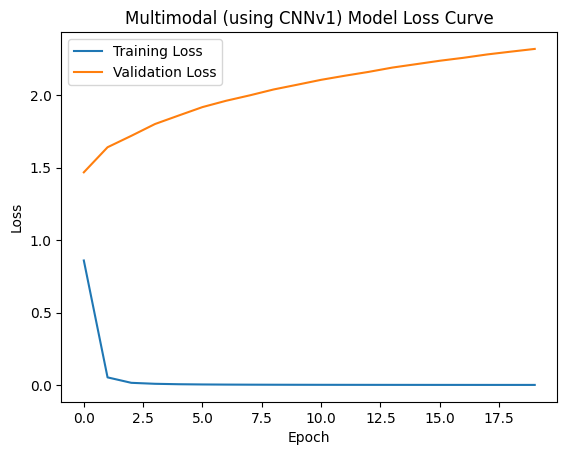

In [108]:
plt.plot(multimodal_history.history['loss'], label='Training Loss')
plt.plot(multimodal_history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Multimodal (using CNNv1) Model Loss Curve')
plt.legend()

plt.show()

In [109]:
multimodal.evaluate(X_test_m, y_test_m)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5524 - loss: 2.3193 


[2.3192501068115234, 0.5524475574493408]

In [ ]:
RESULTS = {
    'CNN v1': {'train': 0.9956, 'test': 0.5175},
    'CNN v2': {'train': 0.5819, 'test': 0.5175},
    'RNN LSTM': {'train': 0.1209, 'test': 0.1376},
    'RNN GRU': {'train': 0.1288, 'test': 0.1376},
    'Early Fusion v1': {'train': 1.0000, 'test': 0.5524},
    'Early Fusion v2': {'train': 1.0000, 'test': 0.5490},
    'Late Fusion': {'train': None, 'test': 0.4125},
}

cnn: training accuracy = 0.9956, testing accuracy = 0.5175          -   severe overfitting

rnn_lstm: training accuracy = 0.1209, testing accuracy = 0.1376     -   almost random (1/8)

rnn_gru: training accuracy = 0.1288, testing accuracy = 0.1376      -   almost random (1/8)

multimodal: training accuracy = 1.0000, testing accuracy = 0.5524   -   overfitting



Our biggest issue is the severe overfitting in the CNN. We can tackle this using:
 - Batch Normalization
 - Increasing Dropout probability
 - Decreasing complexity of our network
 - GlobalAveragePooling2D instead of Flatten



In [110]:
from tensorflow.keras.layers import (BatchNormalization, GlobalAveragePooling2D)

In [111]:
cnn_new = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=X_train.shape[1:]),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.2),

    Conv2D(64, (3,3), activation="relu", padding="same"),

    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation="relu", padding="same"),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(64, activation="relu"),

    Dropout(0.2),

    Dense(8, activation="softmax")
])

c:\Python 3.13\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
cnn_new.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [113]:
cnn2_history = cnn_new.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 34s 922ms/step - accuracy: 0.2270 - loss: 1.9631 - val_accuracy: 0.1364 - val_loss: 19.3848
Epoch 2/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 33s 920ms/step - accuracy: 0.2954 - loss: 1.7811 - val_accuracy: 0.1329 - val_loss: 12.9735
Epoch 3/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 981ms/step - accuracy: 0.3514 - loss: 1.6849 - val_accuracy: 0.1399 - val_loss: 5.7037
Epoch 4/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 987ms/step - accuracy: 0.3935 - loss: 1.6041 - val_accuracy: 0.1329 - val_loss: 10.5141
Epoch 5/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 35s 983ms/step - accuracy: 0.3909 - loss: 1.5610 - val_accuracy: 0.1364 - val_loss: 5.4209
Epoch 6/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 994ms/step - accuracy: 0.4382 - loss: 1.4773 - val_accuracy: 0.1469 - val_loss: 3.2287
Epoch 7/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 1s/step - accuracy: 0.4610 - loss: 1.4111 - val_accuracy: 0.1329 - val_loss: 3.2975
Epoch 8/15
36/36 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.4864 - loss: 1.3944 - val_accurac

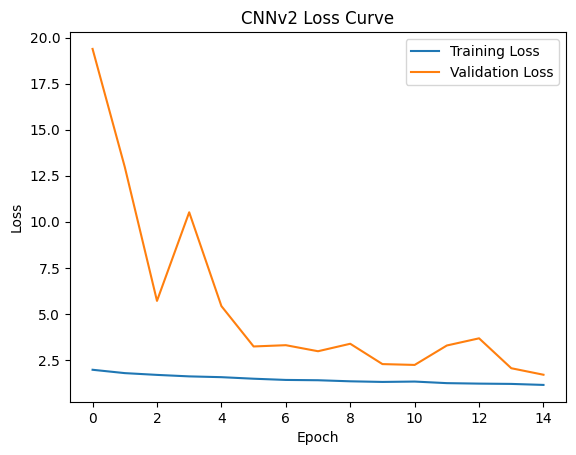

In [114]:
plt.plot(cnn2_history.history['loss'], label='Training Loss')
plt.plot(cnn2_history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNNv2 Loss Curve')
plt.legend()

plt.show()

In [115]:
model_cnn.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.5175 - loss: 2.2973


[2.2972822189331055, 0.5174825191497803]

In [116]:
from sklearn.metrics import confusion_matrix

y_pred = cnn_new.predict(X_test)

y_pred = np.argmax(y_pred, axis=1)

cm = confusion_matrix(y_test, y_pred)

print(cm)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
[[ 1 14  0  0  0  0  0  4]
 [ 1 35  0  0  0  0  0  2]
 [ 0  6  0  0  5  3  4 21]
 [ 0 19  0  0  1  2 10  6]
 [ 0  3  0  0 10  0  9 17]
 [ 0  6  0  0  3  9  2 17]
 [ 0  6  0  0  1  0 21 10]
 [ 0  0  0  0  0  0  0 38]]


As we can clearly see, our model has learned only a few dominant emotional clusters.

In [117]:
for i, layer in enumerate(cnn_new.layers):
    print(f"{i}, {layer.name}")

0, conv2d_4
1, batch_normalization
2, max_pooling2d_4
3, dropout_4
4, conv2d_5
5, max_pooling2d_5
6, conv2d_6
7, batch_normalization_1
8, max_pooling2d_6
9, dropout_5
10, global_average_pooling2d
11, dense_11
12, dropout_6
13, dense_12


In [118]:
X_aligned = []
for path in df_text["path"]:
    mel_spec = extract_mel_spectrogram(path)
    X_aligned.append(mel_spec)

X_aligned = np.array(X_aligned)[..., np.newaxis]

cnn_extractor = Sequential([
    Conv2D(32, (3,3), activation="relu", padding="same", input_shape=X_train.shape[1:]),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.2),

    Conv2D(64, (3,3), activation="relu", padding="same"),

    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation="relu", padding="same"),

    BatchNormalization(),

    MaxPooling2D((2,2)),

    Dropout(0.3),

    GlobalAveragePooling2D(),

    Dense(64, activation="relu")
])

# we are creating a dummy and sending it through the truncated model because Keras doesn't build the layer weights until the model sees actual data
dummy = np.zeros((1, *X_aligned.shape[1:]))
_ = cnn_extractor(dummy)

cnn_extractor.layers[0].set_weights(cnn_new.layers[0].get_weights()) # Conv2D
cnn_extractor.layers[4].set_weights(cnn_new.layers[4].get_weights()) # Conv2D_1
cnn_extractor.layers[6].set_weights(cnn_new.layers[6].get_weights()) # Conv2D_2
cnn_extractor.layers[11].set_weights(cnn_new.layers[11].get_weights()) # Dense(64)

X_audio_features = cnn_extractor.predict(X_aligned)
print("Audio features:", X_audio_features.shape)

c:\Python 3.13\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


45/45 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step
Audio features: (1427, 64)


In [119]:
X_combined = np.concatenate([X_audio_features, X_text_features], axis=1)
y_combined = df_text["emotion"].values.astype(int) - 1

print("X_combined:", X_combined.shape)
print("y_combined:", y_combined.shape)

X_combined: (1427, 128)
y_combined: (1427,)


In [120]:
multimodal.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

In [ ]:
multimodal_history = multimodal.fit(
    X_train_m, 
    y_train_m, 
    epochs=20, 
    batch_size=32, 
    validation_data=(X_test_m, y_test_m)
)

Epoch 1/20


36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 8.0134e-08 - val_accuracy: 0.5524 - val_loss: 4.2455
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 7.7523e-08 - val_accuracy: 0.5524 - val_loss: 4.2532
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 7.5015e-08 - val_accuracy: 0.5524 - val_loss: 4.2618
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 7.2090e-08 - val_accuracy: 0.5524 - val_loss: 4.2718
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.9687e-08 - val_accuracy: 0.5524 - val_loss: 4.2820
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.7597e-08 - val_accuracy: 0.5524 - val_loss: 4.2906
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.4567e-08 - val_accuracy: 0.5524 - val_loss: 4.2961
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 6.0911e-08 - val_accurac

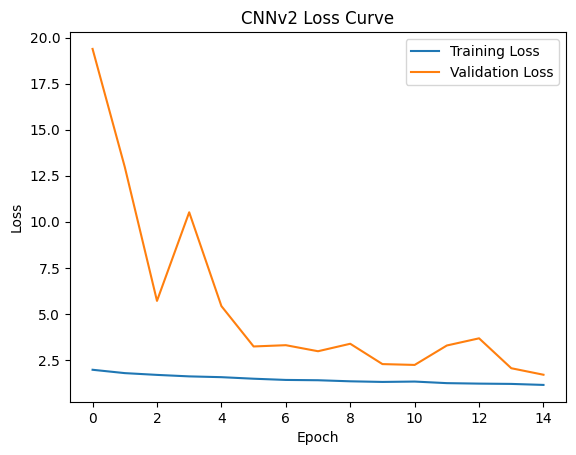

In [125]:
plt.plot(cnn2_history.history['loss'], label='Training Loss')
plt.plot(cnn2_history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNNv2 Loss Curve')
plt.legend()

plt.show()

In [126]:
multimodal.evaluate(X_test_m, y_test_m)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5490 - loss: 4.3917 


[4.3917131423950195, 0.5489510297775269]

## Late Fusion

We consider the Audio CNN and Text RNN as two completely separate models, then obtain the probability outputs (Softmax scores) from both.


In [127]:
cnn_probs = cnn_new.predict(X_test)
cnn_probs.shape

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step


(286, 8)

In [128]:
rnn_probs = model_rnn.predict(X_test_sq)
rnn_probs.shape

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


(286, 8)

In [129]:
final_probs = 0.9 * cnn_probs + 0.1 * rnn_probs # since our CNN is much stronger

y_pred = np.argmax(final_probs, axis=1)

In [130]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(cm, accuracy)

[[ 1 14  0  0  0  0  0  4]
 [ 1 35  0  0  0  0  0  2]
 [ 0  6  0  0  5  3  4 21]
 [ 0 19  0  0  1  2 10  6]
 [ 0  3  0  0 10  0  9 17]
 [ 0  6  0  0  3  9  2 17]
 [ 0  6  0  0  1  0 21 10]
 [ 0  0  0  0  0  0  0 38]] 0.3986013986013986


In [134]:
RESULTS = {
    'CNN v1': {'train': 0.9956, 'test': 0.5175},
    'CNN v2': {'train': 0.5819, 'test': 0.5175},
    'RNN LSTM': {'train': 0.1209, 'test': 0.1376},
    'RNN GRU': {'train': 0.1288, 'test': 0.1376},
    'Early Fusion v1': {'train': 1.0000, 'test': 0.5524},
    'Early Fusion v2': {'train': 1.0000, 'test': 0.5490},
    'Late Fusion': {'train': None, 'test': 0.3986},
}

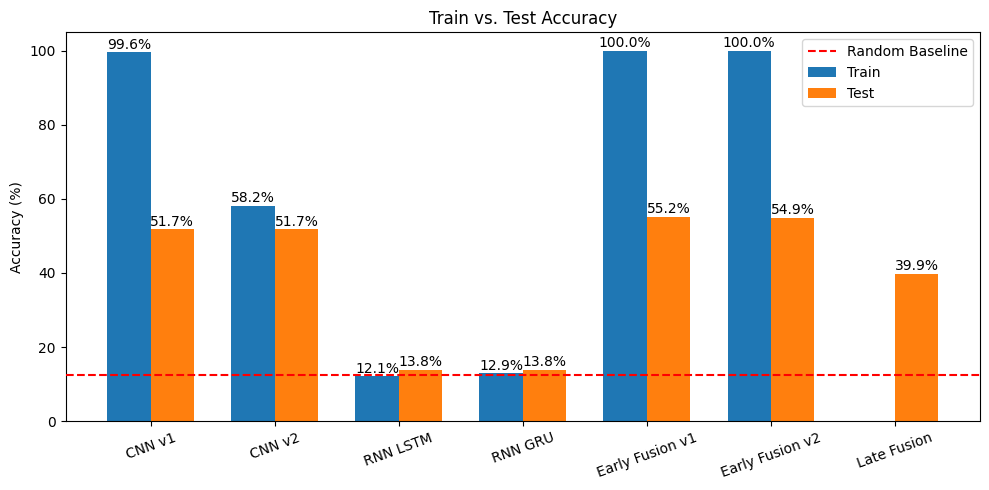

In [135]:
# accuracy comparison

labels = list(RESULTS.keys())

train_acc = [
    RESULTS[m]['train'] * 100 if RESULTS[m]['train'] is not None else 0
    for m in labels
]

test_acc = [
    RESULTS[m]['test'] * 100
    for m in labels
]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width/2, train_acc, width, label='Train')
bars2 = plt.bar(x + width/2, test_acc, width, label='Test')

for bar in bars1:
    height = bar.get_height()
    if height != 0:
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f'{height:.1f}%',
            ha='center'
        )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.axhline(12.5, color='red', linestyle='--', label='Random Baseline', zorder=1000)

plt.xticks(x, labels, rotation=20)
plt.ylabel('Accuracy (%)')
plt.title('Train vs. Test Accuracy')
plt.legend()

plt.tight_layout()
plt.savefig("accuracy_comparison.png")
plt.show()

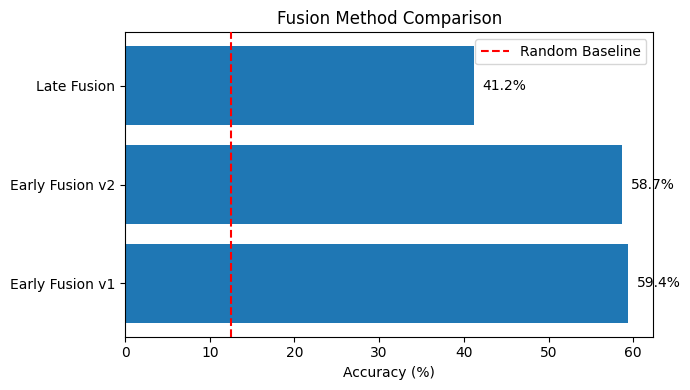

In [136]:
# fusion method comparison

fusion_labels = [
    'Early Fusion v1',
    'Early Fusion v2',
    'Late Fusion'
]

fusion_values = [
    59.4,
    58.7,
    41.2
]

plt.figure(figsize=(7, 4))

bars = plt.barh(fusion_labels, fusion_values)

for bar in bars:
    width_val = bar.get_width()
    plt.text(
        width_val + 1,
        bar.get_y() + bar.get_height()/2,
        f'{width_val:.1f}%',
        va='center'
    )

plt.axvline(12.5, color='red', linestyle='--', label='Random Baseline', zorder=1000)

plt.xlabel('Accuracy (%)')
plt.title('Fusion Method Comparison')
plt.legend()

plt.tight_layout()
plt.savefig("late_fusion_comparison.png")
plt.show()